In [1]:
# imports
import datetime
import math
import time

import numpy as np
import pyodbc
import pandas as pd
from matplotlib import pyplot as plt
from pandas import DataFrame
from pyodbc import Row

In [ ]:
def time_to_seconds(_time: datetime.time) -> int:
    """
    params:
    _time in [00:00:00, 23:59:59]

    returns:
    out in [0, 86399]
    """
    return _time.hour * 3600 + _time.minute * 60 + _time.second


def seconds_to_time(total_seconds: int) -> datetime.time:
    """
    params:
    total_seconds in [0, 86399]

    returns:
    out in [00:00:00, 23:59:59]
    """
    if not (0 <= total_seconds < 86399):
        raise ValueError

    hour = total_seconds // 3600
    remaining_seconds = total_seconds % 3600

    minute = remaining_seconds // 60
    second = remaining_seconds % 60

    return datetime.time(hour=hour, minute=minute, second=second)


def format_time_to_ms(_time: float) -> str:
    return f"{_time * 1000:.2f}ms"


def format_time(seconds: float) -> str:
    log_seconds: float = math.log10(seconds)

    match log_seconds:
        case _ if 0 <= log_seconds:
            return f"{seconds:.2f}s"

        case _ if -3 <= log_seconds < 0:
            return f"{seconds * 1000:.2f}ms"

        case _:
            return "<000.00ms"

In [20]:
# configs
name_map: dict[str, str] = {
    "dow": "day_of_week",
    "dom": "day_of_month",
    "doy": "day_of_year",
    "wn": "week_number",
    "mn": "month_number",
    "qn": "quarter_number",
    "yn": "year_number",
}


def sql_grain_pt(grain: str) -> str:
    return f"""
    SELECT
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
            AS diff_purchase_to_approve_s,
        COUNT(*) AS order_count
    FROM sales.vw_orders_practical AS o
    GROUP BY
        o.{grain},
        CONVERT(TIME, o.order_purchase_timestamp),
        DATEDIFF(SECOND, o.order_purchase_timestamp, order_approved_at)
    ORDER BY
        o.{grain},
        purchase_time,
        diff_purchase_to_approve_s
    """


sql_day_pt = """
    SELECT
        CONVERT(TIME, o.order_purchase_timestamp) AS purchase_time,
        COUNT(*) AS order_count
    FROM sales.vw_orders_practical AS o
    GROUP BY CONVERT(TIME, o.order_purchase_timestamp)
    ORDER BY purchase_time;
"""

# connect
driver = "ODBC Driver 17 for SQL Server"
server = "localhost"
database = "olist"

connstring: str = f"""
    DRIVER={{{driver}}};
    SERVER={server};
    DATABASE={database};
    Trusted_Connection=yes;
"""
tik_connect = time.perf_counter()
conn = pyodbc.connect(connstring, timeout=60)
cursor = conn.cursor()
tok_connect = time.perf_counter()

# get day table
tik_day_table = time.perf_counter()
day_pt_rows: list[Row] = cursor.execute(sql_day_pt).fetchall()

day_pt_columns: list[str] = [description[0] for description in cursor.description]
df_day_pt: DataFrame = pd.DataFrame(
    (tuple(r) for r in day_pt_rows), columns=day_pt_columns
)
tok_day_table = time.perf_counter()

# get other tables
tik_other_tables = time.perf_counter()
dfs_pt: dict[str, DataFrame] = {}

for name in name_map:
    df_name = f"{name}"
    grain = name_map[name]

    sql = sql_grain_pt(grain=grain)
    grain_pt_rows: list[Row] = cursor.execute(sql).fetchall()

    grain_pt_columns: list[str] = [description[0] for description in cursor.description]
    df_grain_pt = pd.DataFrame(
        (tuple(r) for r in grain_pt_rows), columns=grain_pt_columns
    )

    dfs_pt[df_name] = df_grain_pt
tok_other_tables = time.perf_counter()

conn.close()

print(f"{format_time_to_ms(tok_connect - tik_connect)}: Time to connect to DB")
print(f"{format_time_to_ms(tok_day_table - tik_day_table)}: Query day table")
print(f"{format_time_to_ms(tok_other_tables - tik_other_tables)}: Query other tables")

14.65ms: Time to connect to DB
10480.83ms: Query day table
3007.15ms: Query other tables


In [31]:
# clean
time_to_seconds_column_name = "purchase_time_s"

tik_day = time.perf_counter()
if not df_day_pt.columns.str.contains(time_to_seconds_column_name).any():
    df_day_pt[time_to_seconds_column_name] = df_day_pt["purchase_time"].apply(
        time_to_seconds
    )
tok_day = time.perf_counter()

tik_other = time.perf_counter()
for i in dfs_pt:
    if not dfs_pt[i].columns.str.contains(time_to_seconds_column_name).any():
        dfs_pt[i][time_to_seconds_column_name] = dfs_pt[i]["purchase_time"].apply(
            time_to_seconds
        )
tok_other = time.perf_counter()

print(f"Clean `df_pt_day`: {format_time_to_ms(tok_day - tik_day)}")
print(f"Clean `dfs_pt`: {format_time_to_ms(tok_other - tik_other)}")

Clean `df_pt_day`: 0.42ms
Clean `dfs_pt`: 1.01ms


In [5]:
def get_time_bins(size: str = "15m") -> int | None:
    measure: str = size[-1]
    number_part: str = size[:-1]

    try:
        number = float(number_part)
    except ValueError:
        return None

    if number == 0:
        return None

    match measure:
        case "s":
            out = 86400 / number

        case "m":
            out = (60 / number) * 24

        case "h":
            out = 24 / number

        case _:
            return None

    return math.floor(out)

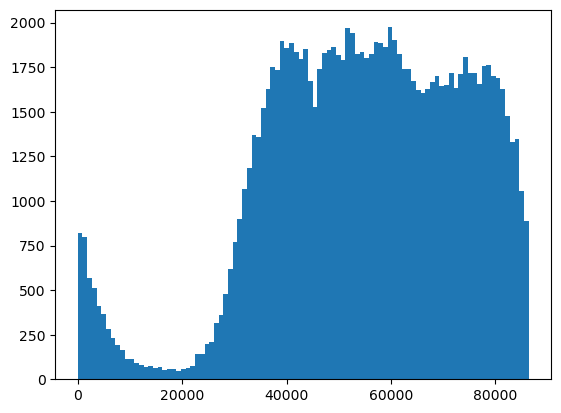

In [6]:
fig, ax = plt.subplots()

x = df_day_pt["purchase_time_s"]
weights = df_day_pt["order_count"]

ax.hist(x, weights=weights, bins=get_time_bins("15m"))
plt.show()